# Demo in Bayesian Experiment Design - Linear Regression

In [1]:
import arviz as az
import numpy as np
import plotly.express as px
import pytensor.tensor as pt
import scipy.stats as sps
from numpy.typing import NDArray
from pymc import HalfCauchy, Model, Normal, sample

## Generate Toy Data

In [2]:
def generate_toy_data() -> tuple[NDArray, NDArray]:
    """Generate toy data.

    The data is generated from a simple linear regression model with
    the true intercept of 1 and slope of 2, with added Gaussian noise.

    Returns
    -------
    tuple[NDArray, NDArray]
        The generated toy data.

    """
    np.random.seed(42)

    size = 200
    true_intercept = 1
    true_slope = 2

    x = np.linspace(0, 1, size)
    # y = a + b*x
    true_regression_line = true_intercept + true_slope * x
    # add noise
    y = true_regression_line + np.random.normal(loc=0, scale=0.5, size=size)

    # Plot the generated data
    figure = px.scatter(x=x, y=y, title="Generated Data")
    figure.add_trace(
        px.line(
            x=x,
            y=true_regression_line,
            title="True Regression Line",
        ).data[0],
    )
    figure.show()

    return x, y

In [3]:
x, y = generate_toy_data()

## Fit a Linear Regression model

In [6]:
from typing import Self

import pymc as pm
from pymc_extras.model_builder import ModelBuilder

In [ ]:
class LinearModel(ModelBuilder):
    """Linear model."""

    _model_type = "LinearModel"

    # And a version
    version = "0.1"

    def build_model(self, X: NDArray, y: NDArray, **kwargs):
        """Build_model creates the PyMC model.

        Parameters
        ----------
        model_config : dict
            it is a dictionary with all the parameters that we need in
            our model example:  a_loc, a_scale, b_loc
        X : NDArray
            The input data that is going to be used in the model. This should be a DataFrame
            containing the features (predictors) for the model. For efficiency reasons, it should
            only contain the necessary data columns, not the entire available dataset, as this
            will be encoded into the data used to recreate the model.

        y : pd.Series
            The target data for the model. This should be a Series representing the output
            or dependent variable for the model.

        kwargs : dict
            Additional keyword arguments that may be used for model configuration.
        """
        # Check the type of X and y and adjust access accordingly
        X_values = X
        y_values = y
        self._generate_and_preprocess_model_data(X_values, y_values)

        with pm.Model(coords=self.model_coords) as self.model:
            # Create mutable data containers
            x_data = pm.MutableData("x_data", X_values)
            y_data = pm.MutableData("y_data", y_values)

            # prior parameters
            a_mu_prior = self.model_config.get("a_mu_prior", 0.0)
            a_sigma_prior = self.model_config.get("a_sigma_prior", 1.0)
            b_mu_prior = self.model_config.get("b_mu_prior", 0.0)
            b_sigma_prior = self.model_config.get("b_sigma_prior", 1.0)
            eps_prior = self.model_config.get("eps_prior", 1.0)

            # priors
            a = pm.Normal("a", mu=a_mu_prior, sigma=a_sigma_prior)
            b = pm.Normal("b", mu=b_mu_prior, sigma=b_sigma_prior)
            eps = pm.HalfNormal("eps", eps_prior)

            _likelihood = pm.Normal(
                "y",
                mu=a + b * x_data,
                sigma=eps,
                shape=x_data.shape,
                observed=y_data,
            )

    def _data_setter(
        self,
        X: NDArray,
        y: NDArray
    ):
        x_values = X[:, 0]

        with self.model:
            pm.set_data({"x_data": x_values})
            if y is not None:
                pm.set_data(
                    {"y_data": y.values if isinstance(y, pd.Series) else y}
                )

    @staticmethod
    def get_default_model_config() -> Dict:
        """
        Returns a class default config dict for model builder if no model_config is provided on class initialization.
        The model config dict is generally used to specify the prior values we want to build the model with.
        It supports more complex data structures like lists, dictionaries, etc.
        It will be passed to the class instance on initialization, in case the user doesn't provide any model_config of their own.
        """
        model_config: Dict = {
            "a_mu_prior": 0.0,
            "a_sigma_prior": 1.0,
            "b_mu_prior": 0.0,
            "b_sigma_prior": 1.0,
            "eps_prior": 1.0,
        }
        return model_config

    @staticmethod
    def get_default_sampler_config() -> Dict:
        """
        Returns a class default sampler dict for model builder if no sampler_config is provided on class initialization.
        The sampler config dict is used to send parameters to the sampler .
        It will be used during fitting in case the user doesn't provide any sampler_config of their own.
        """
        sampler_config: Dict = {
            "draws": 1_000,
            "tune": 1_000,
            "chains": 3,
            "target_accept": 0.95,
        }
        return sampler_config

    @property
    def output_var(self):
        return "y"

    @property
    def _serializable_model_config(self) -> Dict[str, Union[int, float, Dict]]:
        """
        _serializable_model_config is a property that returns a dictionary with all the model parameters that we want to save.
        as some of the data structures are not json serializable, we need to convert them to json serializable objects.
        Some models will need them, others can just define them to return the model_config.
        """
        return self.model_config

    def _save_input_params(self, idata) -> None:
        """
        Saves any additional model parameters (other than the dataset) to the idata object.

        These parameters are stored within `idata.attrs` using keys that correspond to the parameter names.
        If you don't need to store any extra parameters, you can leave this method unimplemented.

        Example:
            For saving customer IDs provided as an 'customer_ids' input to the model:
            self.customer_ids = customer_ids.values #this line is done outside of the function, preferably at the initialization of the model object.
            idata.attrs["customer_ids"] = json.dumps(self.customer_ids.tolist())  # Convert numpy array to a JSON-serializable list.
        """
        pass

        pass

    def _generate_and_preprocess_model_data(
        self,
        X: Union[pd.DataFrame, pd.Series],
        y: Union[pd.Series, np.ndarray],
    ) -> None:
        """
        Depending on the model, we might need to preprocess the data before fitting the model.
        all required preprocessing and conditional assignments should be defined here.
        """
        self.model_coords = None  # in our case we're not using coords, but if we were, we would define them here, or later on in the function, if extracting them from the data.
        # as we don't do any data preprocessing, we just assign the data given by the user. Note that it's a very basic model,
        # and usually we would need to do some preprocessing, or generate the coords from the data.
        self.X = X
        self.y = y

In [43]:
def fit_and_draw_samples(x: NDArray, y: NDArray) -> az.InferenceData:
    """Draw posterior samples from a Bayesian linear regression.

    Parameters
    ----------
    x, y : NDArray
        The toy data.

    Returns
    -------
    InferenceData
        The posterior samples.

    """
    with Model() as _model:
        sigma = HalfCauchy("sigma", beta=10)
        intercept = Normal("Intercept", 0, sigma=20)
        slope = Normal("slope", 0, sigma=20)

        _likelihood = Normal(
            "y",
            mu=intercept + slope * (1 - pt.exp(-x / slope)),
            sigma=sigma,
            observed=y,
        )

        idata = sample(
            draws=2000,
            tune=1000,
            chains=4,
            cores=4,
            random_seed=42,
            progressbar=True,
        )

        return idata

In [44]:
idata: az.InferenceData = fit_and_draw_samples(x, y)

Initializing NUTS using jitter+adapt_diag...
INFO	Task(Task-2) pymc.sampling.mcmc:mcmc.py:init_nuts()- Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
INFO	Task(Task-2) pymc.sampling.mcmc:mcmc.py:sample()- Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, Intercept, slope]
INFO	Task(Task-2) pymc.sampling.mcmc:mcmc.py:_print_step_hierarchy()- NUTS: [sigma, Intercept, slope]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 1 seconds.
INFO	Task(Task-2) pymc.sampling.mcmc:mcmc.py:_sample_return()- Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 1 seconds.


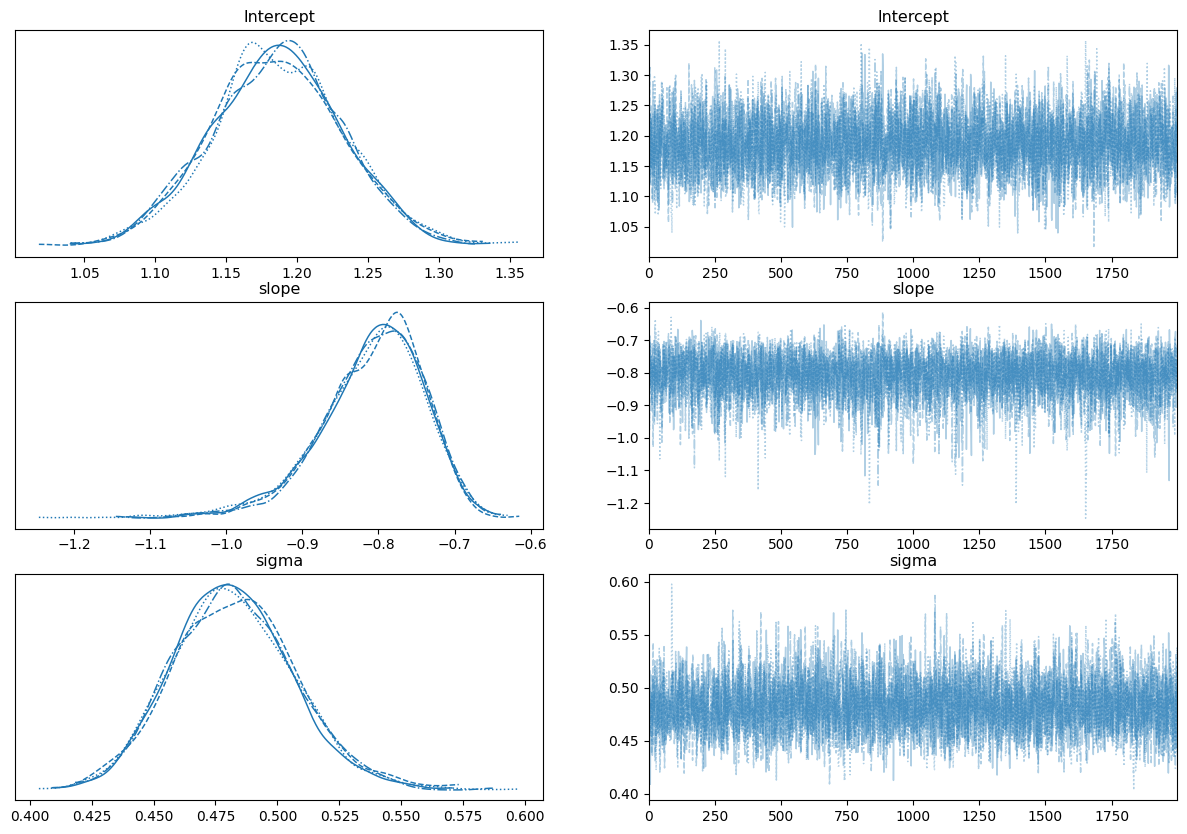

In [45]:
az.plot_trace(idata, figsize=(15, 10));

## Utility Function Definition

In this demo, we will use the expected information gain (EIG) as the utility function. This utility function is essentially the Kullback-Leibler divergence between the prior and posterior distributions. Let's also note that, in this case, the terms "prior" and "posterior" here are considered relative to the experiment (not relative to the model fitted above). Specifically, the "prior" distribution is actually the "posterior" distributions of the model fitted above while the "posterior" distribution is the distribution after the experiment has been carried out.

Mathematically, the expected information gain (EIG) is defined as a function of the experiment $d$ as follows:

$$
\begin{align*}
    EIG(d) & = E_{p(y, \theta | d)} \left[ \log \frac{p(\theta | y, d)}{p(\theta)}\right] \\
    & = E_{p(y, \theta | d)} \left[ \log \frac{p(\theta, y | d)}{p(\theta) \times p(y | d)}\right] \\
    & = E_{p(y, \theta | d)} \left[ \log \frac{p(y | \theta, d)}{p(y | d)}\right]
\end{align*}
$$

To calculate EIG involves a nested expectation over two variables: $\theta$ (the interested parameter) and $y$ (the response). A common way to estimate this is to use a nested Monte Carlo method (NMC):

$$
    E_{p(y, \theta | d)} \left[ \log \frac{p(y | \theta, d)}{p(y | d)}\right] \approx \frac{1}{N} \sum_{n=1}^N \log \frac{p(y_n | \theta_{n, 0}, d)}{\frac{1}{M} \sum_{m=1}^M p(y_n | \theta_{n, m}, d)}
$$

where:
- $\theta_{n, m} \sim p(\theta)$: for this, we will use right away the samples drawn when fitting the linear regression model above.
- $y_n \sim p(y | \theta_{n, 0}, d)$: for this, we need to draw more samples under the constraint of a given experiment.

Based on a research paper, the optimal choices of $M$ and $N$ are $M \approx \sqrt{N}$.

Now, let's specify the scope of our demo. Let's suppose that our experiments only involve changing the value of the variable $x$, and we are only interested in the slope variable.

In other words, the specifications of our demo are:
- $d$: the experiment changes the value of $x$ to take discrete values in either of the following: $[-1, -0.5, 0, 0.5, 1]$.
- $\theta$: the variable we're interested in is the slope.

We will use point estimates for other variables used in the calculation of the EIG.

In [ ]:
def expected_information_gain(
    x: float,
    slope_samples: NDArray[np.float64],
    intercept_est: float,
    sigma_est: float,
) -> float:
    """Estimate the expected information gain (EIG).

    Parameters
    ----------
    x : float
        The experiment design point.
    slope_samples : NDArray[np.float64] of shape (N, M)
        The posterior samples of the slope.
    intercept_est : float
        The point estimate of the intercept.
    sigma_est : float
        The point estimate of the noise.

    Returns
    -------
    float
        The estimated EIG at the design point.

    """
    np.random.seed(42)

    y_samples = np.random.normal(
        loc=slope_samples[:, 0] * x + intercept_est, scale=sigma_est
    )

    return np.log(
        sps.norm.pdf(
            x=y_samples,
            loc=slope_samples[:, 0] * x + intercept_est,
            scale=sigma_est,
        )
        / sps.norm.pdf(
            y_samples[:, np.newaxis],
            loc=slope_samples[:, 1:] * x + intercept_est,
            scale=sigma_est,
        ).mean(axis=1)
    ).mean()


In [9]:
slope_samples = idata.posterior["slope"].values.flatten().reshape(800, 30)
intercept_est = idata.posterior["Intercept"].values.mean()
sigma_est = idata.posterior["sigma"].values.mean()

experiments = [-1, -0.5, 0, 0.5, 1]
for x in experiments:
    eig = expected_information_gain(x, slope_samples, intercept_est, sigma_est)
    print(f"EIG at x={x}: {eig:.4f}")

EIG at x=-1: 0.0289
EIG at x=-0.5: 0.0074
EIG at x=0: 0.0000
EIG at x=0.5: 0.0071
EIG at x=1: 0.0282


Based on the results above, we can see that the experiment with $x = 1$ or $x=-1$ provides us with the most information about the distribution of the slope parameter while the choice $x = 0$ does not provide any information at all.

## Take-aways

In this demo, I've used a Monte Carlo method to estimate the utility function, and, since it involves nested expectations, the number of samples required is quite large. In this case, I've drawn 6000 posterior samples over 4 chains (24k samples in total). Still, it only provides 800 x 30 samples for a nested estimation.